In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os
os.chdir('/Users/lior/DS6021/DS6021_F26/data')
 
penguins = pd.read_csv('penguins.csv')



In [2]:
bd_subset = penguins.dropna(subset=['bill_depth_mm', 'body_mass_g', 'species']).copy()
X1 = bd_subset[['bill_depth_mm']]
y1 = bd_subset['body_mass_g']
model_bd = LinearRegression().fit(X1, y1)
bd_subset['y_hat'] = model_bd.predict(X1)
bd_subset['residuals'] = bd_subset['body_mass_g'] - bd_subset['y_hat']
 
fl_subset = penguins.dropna(subset=['flipper_length_mm', 'body_mass_g']).copy()
X2 = fl_subset[['flipper_length_mm']]
y2 = fl_subset['body_mass_g']
model_fl = LinearRegression().fit(X2, y2)
fl_subset['y_hat'] = model_fl.predict(X2)
fl_subset['residuals'] = fl_subset['body_mass_g'] - fl_subset['y_hat']

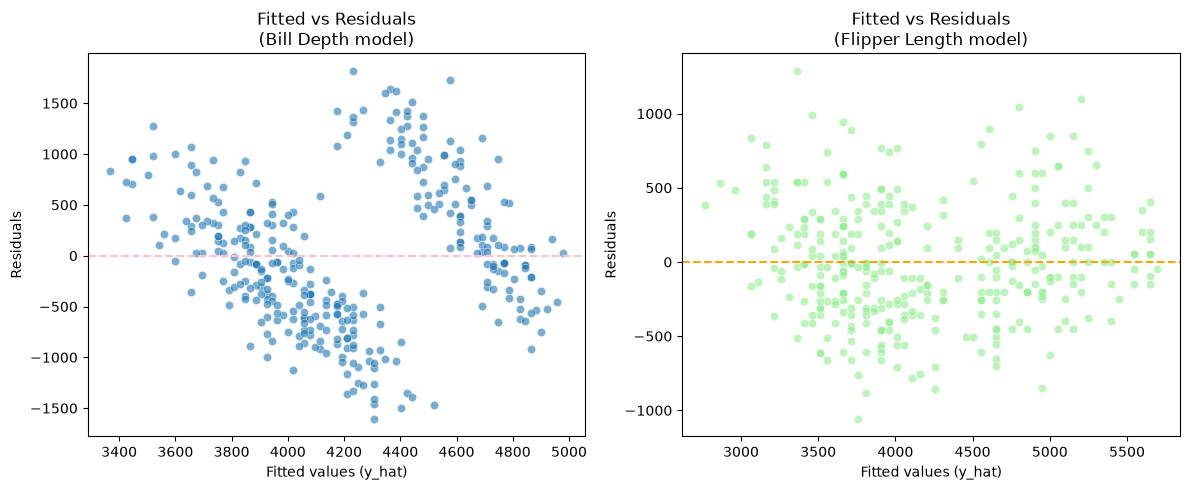

In [ ]:

#part a
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
sns.scatterplot(data=bd_subset, x='y_hat', y='residuals', ax=axes[0], alpha=0.6)
axes[0].axhline(0, color='pink', linestyle='--')
axes[0].set_title('Fitted vs Residuals\n(Bill Depth model)')
axes[0].set_xlabel('Fitted values (y_hat)')
axes[0].set_ylabel('Residuals')
 
sns.scatterplot(data=fl_subset, x='y_hat', y='residuals', ax=axes[1], alpha=0.6, color='lightgreen')
axes[1].axhline(0, color='orange', linestyle='--')
axes[1].set_title('Fitted vs Residuals\n(Flipper Length model)')
axes[1].set_xlabel('Fitted values (y_hat)')
axes[1].set_ylabel('Residuals')
 
plt.tight_layout()
plt.show()

The bill depth model shows two clear clusters both indicating a negative slope and tthis might be because there is some data thats missing. The flipper length shows points scattered everywhere with no clear shape, which is ideally what we shouldve seen in the bill depth model.

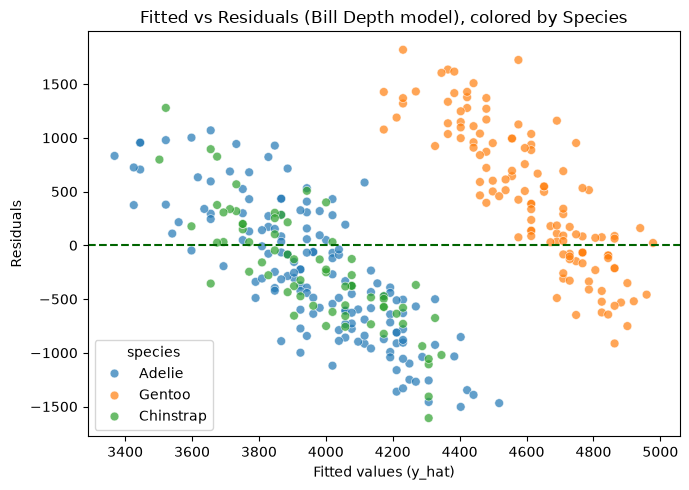

In [7]:
#part b
plt.figure(figsize=(7, 5))
sns.scatterplot(data=bd_subset, x='y_hat', y='residuals', hue='species', alpha=0.7, s=40)
plt.axhline(0, color='darkgreen', linestyle='--')
plt.title('Fitted vs Residuals (Bill Depth model), colored by Species')
plt.xlabel('Fitted values (y_hat)')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

3b

The pattern are three different species, all linear, and gentoo having the highest amounts of body masses and shallower bills. The model doesnt seem to register the species as a variable

In [9]:
# part c

overall_r = np.corrcoef(bd_subset['bill_depth_mm'], bd_subset['body_mass_g'])[0, 1]
print(f"Overall correlation (all species pooled): r = {overall_r:.4f}")
 
for sp, grp in bd_subset.groupby('species'):
    r = np.corrcoef(grp['bill_depth_mm'], grp['body_mass_g'])[0, 1]
    print(f"{sp}: n={len(grp)}, r = {r:.4f}")



Overall correlation (all species pooled): r = -0.4719
Adelie: n=151, r = 0.5761
Chinstrap: n=68, r = 0.6045
Gentoo: n=123, r = 0.7191


3c

Pooling across the different species makes it so that instead of bill depth and body mass being positively correlated, its flipped since gentoos are the heaviest and also have the shallowest bills and its registering the difference between the species instead the actual relationshiop within all the species.


Adelie-only model: n = 151
body_mass_g = -283.28 + 217.15 * bill_depth_mm
R^2 = 0.3319


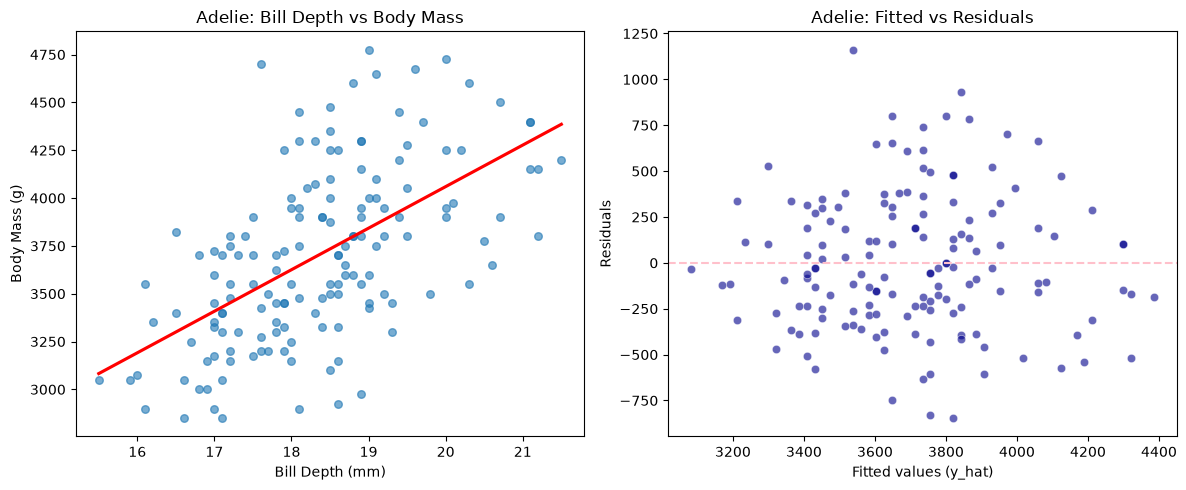

In [ ]:
adelie = penguins[penguins['species'] == 'Adelie'].dropna(
    subset=['bill_depth_mm', 'body_mass_g']).copy()
 
X_a = adelie[['bill_depth_mm']]
y_a = adelie['body_mass_g']
model_a = LinearRegression().fit(X_a, y_a)
adelie['y_hat'] = model_a.predict(X_a)
adelie['residuals'] = adelie['body_mass_g'] - adelie['y_hat']
print(f"\nAdelie-only model: n = {len(adelie)}")
print(f"body_mass_g = {model_a.intercept_:.2f} + {model_a.coef_[0]:.2f} * bill_depth_mm")
print(f"R^2 = {model_a.score(X_a, y_a):.4f}")
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=adelie, x='bill_depth_mm', y='body_mass_g', ci=None, ax=axes[0],
            scatter_kws={'alpha': 0.6, 's': 30}, line_kws={'color': 'red'})
axes[0].set_title('Adelie: Bill Depth vs Body Mass')
axes[0].set_xlabel('Bill Depth (mm)')
axes[0].set_ylabel('Body Mass (g)')
sns.scatterplot(data=adelie, x='y_hat', y='residuals', ax=axes[1], alpha=0.6, color='darkblue')
axes[1].axhline(0, color='pink', linestyle='--')
axes[1].set_title('Adelie: Fitted vs Residuals')
axes[1].set_xlabel('Fitted values (y_hat)')
axes[1].set_ylabel('Residuals')
 
plt.tight_layout()
plt.show()
 

It seems that the plot is now a positive trend and a better predictor of body mass. The line is better fitted and pattern looks random instead of them being cluttered together which is a good sign.